In [33]:
import pandas as pd
df = pd.read_csv("Flipkart_Product.csv", encoding='latin-1')

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 189874 entries, 0 to 189873
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   ProductName  189874 non-null  str  
 1   Price        189874 non-null  str  
 2   Rate         189873 non-null  str  
 3   Review       189870 non-null  str  
 4   Summary      189860 non-null  str  
 5   Sentiment    189874 non-null  str  
dtypes: str(6)
memory usage: 8.7 MB


In [35]:
!pip install emoji


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
import pandas as pd
import re
import nltk
import emoji
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score



# 1. Setup & Data Loading


nltk.download(['punkt', 'stopwords', 'wordnet'], quiet=True)
nltk.download('punkt_tab')

def load_data(file_path):
    for enc in ['utf-8', 'utf-8-sig', 'cp1252', 'latin1']:
        try:
            return pd.read_csv(file_path, encoding=enc)
        except:
            continue
    return pd.read_csv(file_path, encoding='latin1', errors='replace')

df = load_data('Flipkart_Product.csv')



# 2. Cleaning & Preprocessing


df = df.rename(columns={'Review': 'review', 'Sentiment': 'sentiment'})
df['Summary'] = df['Summary'].fillna('No Summary')
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce').fillna(0)
df = df.dropna(subset=['review', 'sentiment'])

df['combined_text'] = df['Summary'].astype(str) + " " + df['review'].astype(str)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
stop_words.difference_update({'not', 'no', 'never'})

def clean_text(text):
    text = emoji.demojize(text)
    text = text.replace(':', ' ').replace('_', ' ').lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    return ' '.join([lemmatizer.lemmatize(w) for w in tokens if w not in stop_words])

print("Cleaning text...")
df['final_review'] = df['combined_text'].apply(clean_text)
df = df[df['final_review'] != ""].reset_index(drop=True)



[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\shirk\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Cleaning text...


In [37]:
# 3. Label Encoding


le = LabelEncoder()
y = le.fit_transform(df['sentiment'])



# 4. Train-Test Split


X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['final_review'],
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



Training Logistic Regression...

--- Logistic Regression Results ---
Accuracy: 92.89%
              precision    recall  f1-score   support

    Negative       0.95      0.97      0.96      5168
     Neutral       0.56      0.93      0.70      3136
    Positive       0.99      0.92      0.96     29670

    accuracy                           0.93     37974
   macro avg       0.84      0.94      0.87     37974
weighted avg       0.95      0.93      0.94     37974



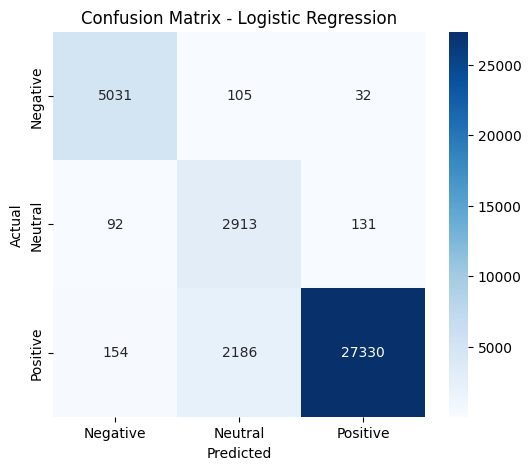

In [38]:
# 5. TF-IDF + Logistic Regression


tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("\n--- Logistic Regression Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.2%}")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

plt.figure(figsize=(6, 5))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()


Training Multinomial Naive Bayes...

--- Naive Bayes Results ---
Accuracy: 94.58%
              precision    recall  f1-score   support

    Negative       0.95      0.93      0.94      5168
     Neutral       0.69      0.73      0.71      3136
    Positive       0.97      0.97      0.97     29670

    accuracy                           0.95     37974
   macro avg       0.87      0.88      0.87     37974
weighted avg       0.95      0.95      0.95     37974



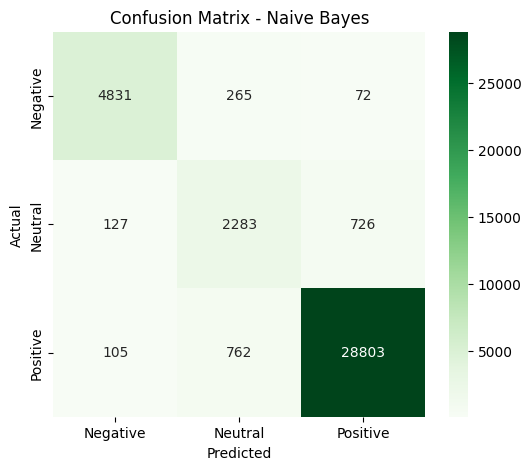

In [39]:
# 6. Bag-of-Words + Naive Bayes


bow = CountVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_bow = bow.fit_transform(X_train_text)
X_test_bow = bow.transform(X_test_text)

print("Training Multinomial Naive Bayes...")
nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)

y_pred_nb = nb_model.predict(X_test_bow)

print("\n--- Naive Bayes Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.2%}")
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))

plt.figure(figsize=(6, 5))
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()


In [40]:
# 7. Model Comparison

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Logistic Regression": [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr, average='weighted'),
        recall_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_lr, average='weighted')
    ],
    "Naive Bayes": [
        accuracy_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_nb, average='weighted'),
        recall_score(y_test, y_pred_nb, average='weighted'),
        f1_score(y_test, y_pred_nb, average='weighted')
    ]
})

comparison = comparison.set_index("Metric").round(4)

print("\n=== Model Performance Comparison ===")
print(comparison)



=== Model Performance Comparison ===
           Logistic Regression  Naive Bayes
Metric                                     
Accuracy                0.9289       0.9458
Precision               0.9527       0.9471
Recall                  0.9289       0.9458
F1-Score                0.9359       0.9464


In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 189870 entries, 0 to 189869
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   ProductName    189870 non-null  str    
 1   Price          189870 non-null  str    
 2   Rate           189870 non-null  float64
 3   review         189870 non-null  str    
 4   Summary        189870 non-null  str    
 5   sentiment      189870 non-null  str    
 6   combined_text  189870 non-null  str    
 7   final_review   189870 non-null  str    
dtypes: float64(1), str(7)
memory usage: 11.6 MB


In [42]:
display(df)

,ProductName,Price,Rate,review,Summary,sentiment,combined_text,final_review
0,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"? 3,999",5.0,Super!,Great cooler.. excellent air flow and for this...,Positive,Great cooler.. excellent air flow and for this...,great cooler excellent air flow price amazing ...
1,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"? 3,999",5.0,Awesome,Best budget 2 fit cooler. Nice cooling,Positive,Best budget 2 fit cooler. Nice cooling Awesome,best budget fit cooler nice cooling awesome
2,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"? 3,999",3.0,Fair,The quality is good but the power of air is de...,Neutral,The quality is good but the power of air is de...,quality good power air decent fair
3,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"? 3,999",1.0,Useless product,Very bad product it's a only a fan,Negative,Very bad product it's a only a fan Useless pro...,bad product fan useless product
4,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"? 3,999",3.0,Fair,Ok ok product,Neutral,Ok ok product Fair,ok ok product fair
...,...,...,...,...,...,...,...,...
189865,"NIVEA Soft Light Moisturizer for Face, Hand & ...",? 142,5.0,Terrific,Good,Positive,Good Terrific,good terrific
189866,"NIVEA Soft Light Moisturizer for Face, Hand & ...",? 142,5.0,Terrific,Thanks,Positive,Thanks Terrific,thanks terrific
189867,"NIVEA Soft Light Moisturizer for Face, Hand & ...",? 142,5.0,Terrific,Good,Positive,Good Terrific,good terrific
189868,"NIVEA Soft Light Moisturizer for Face, Hand & ...",? 142,5.0,Just wow!,Super,Positive,Super Just wow!,super wow


In [43]:
import joblib

joblib.dump(lr_model, "model_lr.pkl")
joblib.dump(nb_model, "model_nb.pkl")
joblib.dump(tfidf, "tfidf.pkl")
joblib.dump(bow, "bow.pkl")

['bow.pkl']

In [46]:
print(le.inverse_transform([0, 1, 2]))

['Negative' 'Neutral' 'Positive']


In [47]:
joblib.dump(le.classes_, "classes.pkl")

['classes.pkl']